# Modeling exploration

Use this notebook to iterate on feature engineering and model behavior locally without Strava API calls.

## Setup

Run once from repo root:
```bash
pip install -r requirements-dev.txt
python -m ipykernel install --user --name train-tomorrow
```

To use live data, set `USE_LIVE_DATA = True` in the next cell. Requires a repo-root `.env` with `STRAVA_CLIENT_ID`, `STRAVA_CLIENT_SECRET`, `STRAVA_REFRESH_TOKEN`, and optionally `FORECAST_LAT`/`FORECAST_LON`.

In [1]:
import logging
import os
import sys
import tempfile
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
from dotenv import load_dotenv
from sklearn.metrics import ConfusionMatrixDisplay, RocCurveDisplay

sys.path.insert(0, str(Path.cwd().parent / "scripts"))  # allow importing sibling scripts modules

from blurb import generate_blurb, generate_blurb_llm
from explain import feature_contributions, summarize_top_contributors
from features import FEATURE_COLUMNS, prepare_datasets
from model import evaluate_models, predict_tomorrow, train_and_save_models, walk_forward_evaluate
from strava_client import fetch_activities_dataframe, out_of_range_dates
from weather_client import DEFAULT_LAT, DEFAULT_LON, fetch_historical_weather, fetch_tomorrow_forecast

logging.basicConfig(level=logging.INFO, format="%(asctime)s %(levelname)s %(name)s: %(message)s", force=True)
load_dotenv(Path.cwd().parent / ".env")  # repo root .env


True

In [10]:

activities = fetch_activities_dataframe(days_back=365*1)
weather = fetch_tomorrow_forecast()
activity_dates = pd.to_datetime(activities['date'], errors='coerce').dt.date.dropna()
historical_weather = (
    fetch_historical_weather(activity_dates.min(), activity_dates.max())
    if not activity_dates.empty
    else None
)
if historical_weather is not None:
    home_lat = float(os.getenv('FORECAST_LAT', DEFAULT_LAT))
    home_lon = float(os.getenv('FORECAST_LON', DEFAULT_LON))
    stale_dates = out_of_range_dates(activities, home_lat, home_lon)
    historical_weather = historical_weather.drop(index=list(stale_dates), errors='ignore')


prepared = prepare_datasets(activities=activities, tomorrow_weather=weather, historical_weather=historical_weather)
prepared.historical[['as_of_date', 'target_date'] + FEATURE_COLUMNS + ['will_train_tomorrow']].tail(2)


2026-10-02 22:34:16,865 INFO strava_client: Fetched 482 activities from Strava. Used 3 pages to get 365 days


,as_of_date,target_date,acute_load_7,chronic_load_28,atl_ctl_ratio,days_since_last_hard,streak_length,trained_today,trained_hard_today,trained_days_2,...,forecast_rain_expected,forecast_wind_speed,forecast_temp_high_vs_seasonal,forecast_temp_low_vs_seasonal,forecast_precip_probability_vs_seasonal,forecast_wind_speed_vs_seasonal,forecast_precip_morning,forecast_precip_midday,forecast_precip_evening,will_train_tomorrow
362,2026-09-30,2026-10-01,32.362366,29.347696,1.102723,0,3,1,1,2.0,...,0,6.6,0.546711,-0.669737,-20.888158,-5.168092,0.0,0.0,0.0,1
363,2026-10-01,2026-10-02,36.021775,30.565096,1.178526,0,4,1,1,2.0,...,0,9.9,2.565132,0.775329,-21.436404,-1.896711,0.0,0.0,0.0,1


In [11]:
with tempfile.TemporaryDirectory() as tmpdir:
    models = train_and_save_models(prepared.historical, Path(tmpdir))
    prediction = predict_tomorrow(models, prepared.tomorrow_features)
    contributions = feature_contributions(models.classifier, prepared.tomorrow_features)

prediction

2026-10-02 22:34:22,928 INFO model: classifier_accuracy=0.699 (baseline=0.685)
2026-10-02 22:34:22,928 INFO model: classifier_auc=0.672
2026-10-02 22:34:22,929 INFO model: classifier_precision=0.741 recall=0.860 f1=0.796
2026-10-02 22:34:22,930 INFO model: refitting classifier on full dataset (n=364) before saving
2026-10-02 22:34:23,538 INFO model: regressor_mae=31.217
2026-10-02 22:34:23,539 INFO model: refitting regressor on full positive-label dataset (n=229) before saving


{'will_train': True,
 'probability': 0.8007182478904724,
 'predicted_effort': 25.231918334960938}

## Model analysis

Confusion matrix / ROC for the classifier, predicted-vs-actual for the regressor, and feature importances — all computed on the same held-out time-based test split used during training.

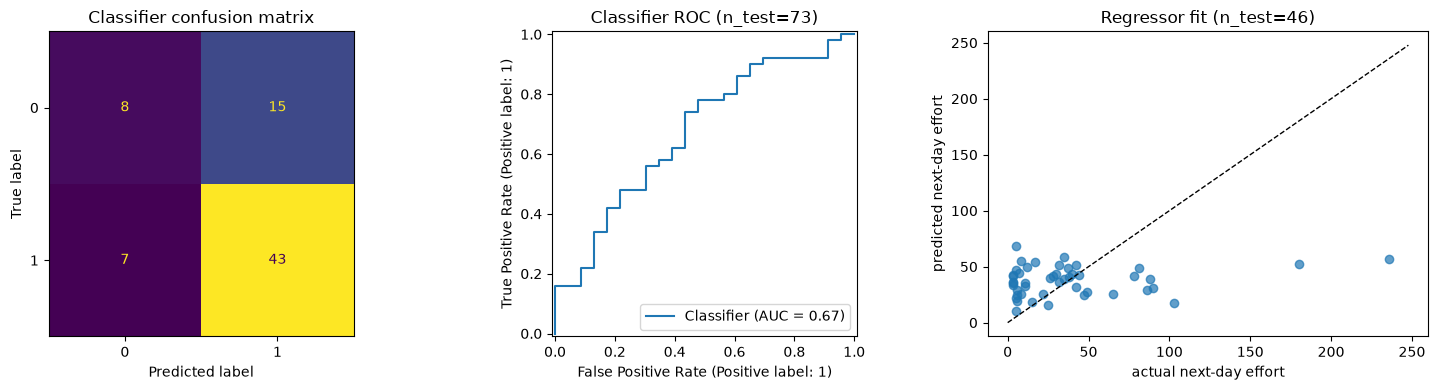

In [12]:
eval_results = evaluate_models(models, prepared.historical)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

ConfusionMatrixDisplay.from_predictions(
    eval_results['y_test'], (eval_results['probs'] >= 0.5).astype(int), ax=axes[0], colorbar=False
)
axes[0].set_title('Classifier confusion matrix')

RocCurveDisplay.from_predictions(eval_results['y_test'], eval_results['probs'], ax=axes[1])
axes[1].set_title(f"Classifier ROC (n_test={len(eval_results['y_test'])})")

axes[2].scatter(eval_results['reg_true'], eval_results['reg_pred'], alpha=0.7)
lims = [0, max(eval_results['reg_true'].max(), eval_results['reg_pred'].max(), 1) * 1.05]
axes[2].plot(lims, lims, 'k--', linewidth=1)
axes[2].set_xlabel('actual next-day effort')
axes[2].set_ylabel('predicted next-day effort')
axes[2].set_title(f"Regressor fit (n_test={len(eval_results['reg_true'])})")

plt.tight_layout()
plt.show()

In [13]:
importance_df = pd.DataFrame({
    'feature': FEATURE_COLUMNS,
    'classifier_importance': models.classifier.feature_importances_,
    'regressor_importance': models.regressor.feature_importances_,
}).sort_values('classifier_importance', ascending=False).reset_index(drop=True)

importance_df

,feature,classifier_importance,regressor_importance
0,trained_days_7,0.076235,0.035907
1,day_of_week,0.061899,0.027992
2,forecast_temp_low,0.051115,0.022004
3,dow_train_rate,0.044010,0.040870
4,forecast_precip_midday,0.039926,0.036044
5,month,0.038527,0.042479
6,forecast_precip_probability_vs_seasonal,0.037962,0.053582
7,chronic_load_28,0.037501,0.028127
8,moving_time_acute_7,0.037161,0.023330
9,trained_days_30,0.036590,0.033261


In [14]:
folds = walk_forward_evaluate(prepared.historical, n_folds=5)
folds

,fold,n_train,n_test,positive_rate,train_auc,auc,accuracy,baseline_accuracy
0,0,182,36,0.666667,1.000000,0.506944,0.527778,0.666667
1,1,218,36,0.805556,1.000000,0.852217,0.833333,0.805556
2,2,254,37,0.729730,1.000000,0.733333,0.702703,0.729730
3,3,291,36,0.638889,0.999800,0.655518,0.611111,0.638889
4,4,327,37,0.729730,0.999842,0.714815,0.756757,0.729730


In [15]:
top_contributors = summarize_top_contributors(contributions, top_n=11)
blurb = generate_blurb(
    will_train=prediction['will_train'],
    probability=prediction['probability'],
    predicted_effort=prediction['predicted_effort'],
    top_contributors=top_contributors,
)
# llm_blurb = generate_blurb_llm(
#     will_train=prediction['will_train'],
#     probability=prediction['probability'],
#     predicted_effort=prediction['predicted_effort'],
#     top_contributors=top_contributors,
#     fallback_blurb=blurb,
# )

pd.DataFrame(top_contributors)
print(blurb)
# print(llm_blurb)

Looks like a go (80%). how peaky your load balance looks is helping, even with the day of the week. Aim for ~25 relative-effort points.


In [16]:
test_output = {
    "date": str(prepared.tomorrow_features.iloc[0]["target_date"]),
    "will_train": bool(prediction["will_train"]),
    "probability": round(float(prediction["probability"]), 4),
    "predicted_effort": (
        round(float(prediction["predicted_effort"]), 2)
        if prediction["predicted_effort"] is not None
        else None
    ),
    "top_contributors": top_contributors,
    "blurb": blurb,
}